In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [31]:
#WAP in python to implement perceptron 
import numpy as np 
from sklearn.linear_model import Perceptron 
from sklearn.metrics import accuracy_score

#Training data
#[Study,hours,Attendance]
x=np.array([
    [1,50],
    [2,55],
    [4,60],
    [5,75],
    [6,80],
    [7,85]
])

#target 
# 0=Fail,1=Pass
y=np.array([0,0,0,1,1,1])

#create Perceptron model
model=Perceptron(max_iter=1000,random_state=42)
model.fit(x,y)

y_pred=model.predict(x)
print("Actual value:",y)
print("Predicted value:",y_pred)

#Accuracy
accuracy=accuracy_score(y,y_pred) 
print("Accuracy:",accuracy*100,"%")

#Model parameters
print("\nWeights:",model.coef_)
print("Bias:",model.intercept_)

#Predict a new student 
new_student=np.array([[4,70]])

prediction=model.predict(new_student)

if prediction[0]==1:
    print("\nNew student prediction :PASS")
else:
    print("\nNew student Prediction:FAIL")




Actual value: [0 0 0 1 1 1]
Predicted value: [0 0 0 0 0 0]
Accuracy: 50.0 %

Weights: [[ 32. -15.]]
Bias: [-6.]

New student Prediction:FAIL


Actual Values:    [0 0 0 1 1 1]
Predicted Values: [0 0 0 1 1 1]

New Student Prediction: Pass


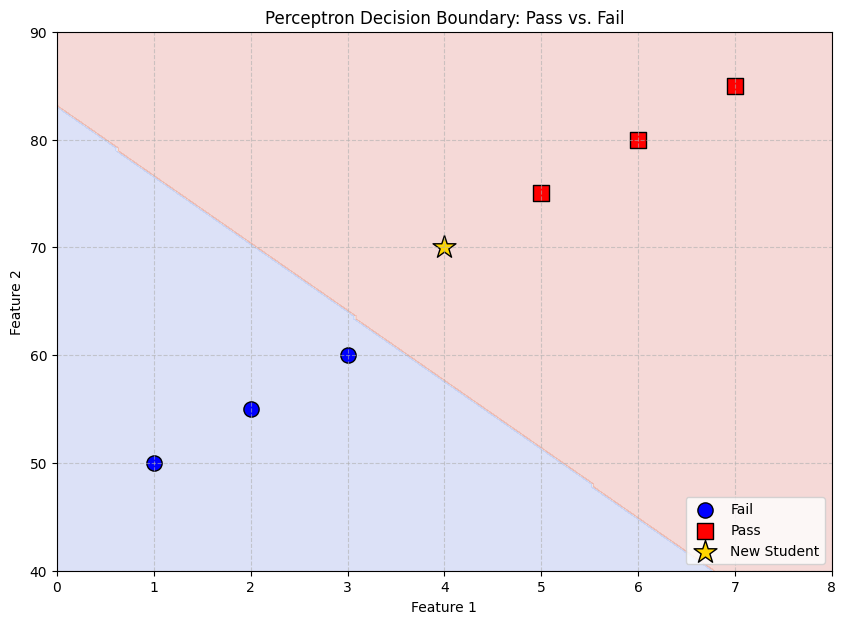

In [32]:

import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import Perceptron 
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import make_pipeline

X = np.array([[1, 50], [2, 55], [3, 60], [5, 75], [6, 80], [7, 85]])
y = np.array([0, 0, 0, 1, 1, 1]) 

model = make_pipeline(StandardScaler(), Perceptron(max_iter=1000, eta0=0.01, random_state=42))
model.fit(X, y)

predictions = model.predict(X)
print("Actual Values:   ", y)
print("Predicted Values:", predictions)

new_student = np.array([[4, 70]])
prediction = model.predict(new_student)

if prediction[0] == 1:
    print('\nNew Student Prediction: Pass')
else:
    print('\nNew Student Prediction: Fail')

x_min, x_max = 0, 8
y_min, y_max = 40, 90

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

z = model.predict(grid)
z = z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, z, alpha=0.2, cmap='coolwarm')
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', s=120, label='Fail', color='blue', edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='s', s=120, label='Pass', color='red', edgecolor='k')
plt.scatter(new_student[:, 0], new_student[:, 1], marker='*', s=300, label='New Student', color='gold', edgecolor='black')

plt.title('Perceptron Decision Boundary: Pass vs. Fail')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

New point: [ 4 70]
Predicted class: 1

Nearest Neighbors:
Neighbor 1: X = [ 5 75], Class = 1, Distance = 0.5991
Neighbor 2: X = [ 3 60], Class = 0, Distance = 0.8903
Neighbor 3: X = [ 6 80], Class = 1, Distance = 1.1981


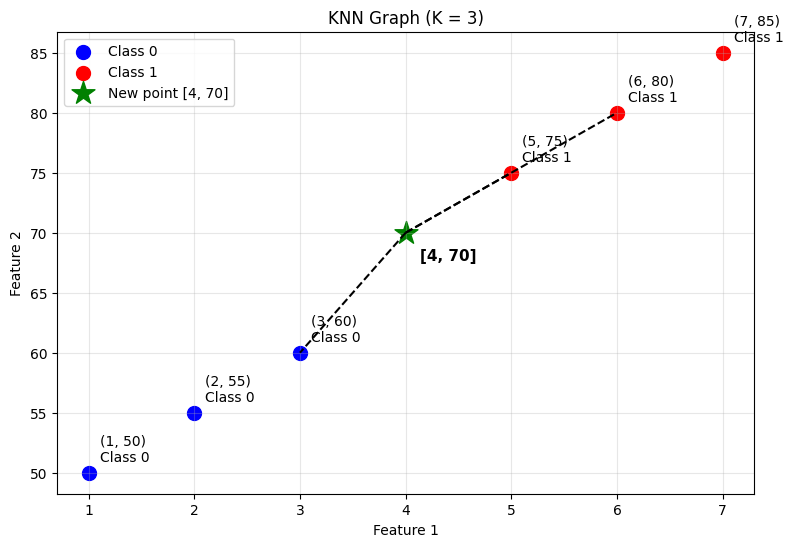

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
X = np.array([
    [2, 55],
    [5, 75],
    [1, 50],
    [6, 80],
    [3, 60],
    [7, 85]
])
y = np.array([0, 1, 0, 1, 0, 1])

x_new = np.array([[4, 70]])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
x_new_scaled = scaler.transform(x_new)
k = 3

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_scaled, y)
prediction = knn.predict(x_new_scaled)
print("New point:", x_new[0])
print("Predicted class:", prediction[0])

distances, indices = knn.kneighbors(x_new_scaled)
print("\nNearest Neighbors:")
for i in range(k):
    index = indices[0][i]
    distance = distances[0][i]
    print(
        f"Neighbor {i+1}: "
        f"X = {X[index]}, "
        f"Class = {y[index]}, "
        f"Distance = {distance:.4f}"
    )
plt.figure(figsize=(9, 6))
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color="blue",
    s=100,
    label="Class 0"
)
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color="red",
    s=100,
    label="Class 1"
)
plt.scatter(
    x_new[0, 0],
    x_new[0, 1],
    color="green",
    marker="*",
    s=300,
    label="New point [4, 70]"
)
for i in range(k):
    index = indices[0][i]
    plt.plot(
        [x_new[0, 0], X[index, 0]],
        [x_new[0, 1], X[index, 1]],
        "k--",
        linewidth=1.5
    )
for i, point in enumerate(X):
    plt.annotate(
        f"({point[0]}, {point[1]})\nClass {y[i]}",
        (point[0], point[1]),
        xytext=(8, 8),
        textcoords="offset points"
    )
plt.annotate(
    "[4, 70]",
    (4, 70),
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"KNN Graph (K = {k})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

   